# Phase 6 - LightGBM Classification

This notebook trains or reuses one fixed-iteration LightGBM model for each Phase 5 imbalance scenario and validates the saved test predictions.

In [1]:
# Cell 1 - Locate the project root and import the notebook dependencies.
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'configs' / 'config.yaml').exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: e:\Paper Multiclass-Intrusion-Detection-System


In [2]:
# Cell 2 - Load shared configuration and verify Phase 5 plus test artifacts exist.
from src.data_loading import load_config, resolve_project_path

config_path = project_root / 'configs' / 'config.yaml'
config = load_config(config_path)
processed_dir = resolve_project_path(config['paths']['processed_dir'], project_root)
models_dir = resolve_project_path(config['paths']['models_dir'], project_root)
metrics_dir = resolve_project_path(config['paths']['metrics_dir'], project_root)
figures_dir = resolve_project_path(config['paths']['figures_dir'], project_root)
figures_dir.mkdir(parents=True, exist_ok=True)

scenarios = config['imbalance']['scenarios']
required_paths = [processed_dir / 'Z_test.npy', processed_dir / 'y_test.npy']
required_paths.extend(
    metrics_dir / f'imbalance_report_{scenario}.json' for scenario in scenarios
)
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Missing Phase 5 or test artifacts: {missing_paths}')

print(f'Scenarios: {scenarios}')
print(f'Configured boosting iterations: {config["lightgbm"]["n_estimators"]}')

Scenarios: ['s1_none', 's2_class_weight', 's3_upsampling', 's4_downsampling']
Configured boosting iterations: 200


In [3]:
# Cell 3 - Train missing models or reuse artifacts with matching source signatures.
from src.classifier import train_all_scenarios

FORCE_RETRAIN_PHASE6 = False
classifier_reports = train_all_scenarios(config_path, force=FORCE_RETRAIN_PHASE6)
training_summary = pd.DataFrame([
    {
        'scenario': report['scenario'],
        'training_rows': report['training_rows'],
        'test_rows': report['test_rows'],
        'iterations': report['model_iterations'],
        'training_seconds': report['training_seconds'],
        'prediction_seconds': report['prediction_seconds'],
        'reused': report.get('reused_existing_artifacts', False),
    }
    for report in classifier_reports.values()
])
display(training_summary)

,scenario,training_rows,test_rows,iterations,training_seconds,prediction_seconds,reused
0,s1_none,4280466,1070117,200,104.975497,10.831626,True
1,s2_class_weight,4280466,1070117,200,104.912774,10.577099,True
2,s3_upsampling,20112470,1070117,200,532.179907,12.209939,True
3,s4_downsampling,1160,1070117,200,1.636508,13.964128,True


In [4]:
# Cell 4 - Validate fixed-iteration training and all configured prediction classes.
expected_classes = list(range(int(config['data']['expected_num_classes'])))
expected_iterations = int(config['lightgbm']['n_estimators'])
for scenario, report in classifier_reports.items():
    assert report['training_classes'] == expected_classes, scenario
    assert report['predicted_classes'] == expected_classes, scenario
    assert report['all_configured_classes_predicted'], scenario
    assert report['model_iterations'] == expected_iterations, scenario
    assert report['model_selection'] == 'fixed_n_estimators', scenario
    assert report['internal_validation'] is False, scenario
    assert report['validation_split_strategy'] == 'not_applicable', scenario
    assert Path(report['model_path']).exists(), scenario
    assert Path(report['prediction_path']).exists(), scenario

print('All model and report validations passed.')
print('No raw-array slicing or internal validation split was used.')

All model and report validations passed.
No raw-array slicing or internal validation split was used.


In [5]:
# Cell 5 - Summarize predicted-class distributions without computing Phase 7 metrics.
index_to_class = {
    int(index): class_name
    for class_name, index in config['data']['class_mapping'].items()
}
distribution_rows = []
for scenario, report in classifier_reports.items():
    predictions = np.load(report['prediction_path'], mmap_mode='r')
    counts = np.bincount(predictions, minlength=len(expected_classes))
    for class_index, count in enumerate(counts):
        distribution_rows.append({
            'scenario': scenario,
            'class_index': class_index,
            'class_name': index_to_class[class_index],
            'prediction_count': int(count),
            'prediction_percentage': 100.0 * count / predictions.shape[0],
        })

prediction_distribution = pd.DataFrame(distribution_rows)
display(prediction_distribution)

,scenario,class_index,class_name,prediction_count,prediction_percentage
0,s1_none,0,Benign,496905,46.434642
1,s1_none,1,Backdoor,5893,0.550687
2,s1_none,2,DDoS,48,0.004485
3,s1_none,3,DoS,149,0.013924
4,s1_none,4,Injection,15436,1.442459
5,s1_none,5,MITM,1450,0.135499
6,s1_none,6,Password,23399,2.186583
7,s1_none,7,Ransomware,1405,0.131294
8,s1_none,8,Scanning,5021,0.469201
9,s1_none,9,XSS,520411,48.631224


In [6]:
# Cell 6 - Confirm the aggregate SHA256 test-integrity check passed.
integrity_path = metrics_dir / 'classifier_test_integrity.json'
with open(integrity_path, encoding='utf-8') as file:
    integrity_report = json.load(file)

assert integrity_report['test_artifacts_unchanged'] is True
assert integrity_report['test_hashes_before'] == integrity_report['test_hashes_after']
assert integrity_report['scenarios'] == scenarios
display(pd.DataFrame([
    {
        'artifact': name,
        'sha256': digest,
        'unchanged': digest == integrity_report['test_hashes_after'][name],
    }
    for name, digest in integrity_report['test_hashes_before'].items()
]))

,artifact,sha256,unchanged
0,Z_test,f48a89f680920f9ee6cf1bba06c660635d4b4722045fd0...,True
1,y_test,764fb8898b5e5c8e6b50135fb64d9988588e0f2036b338...,True


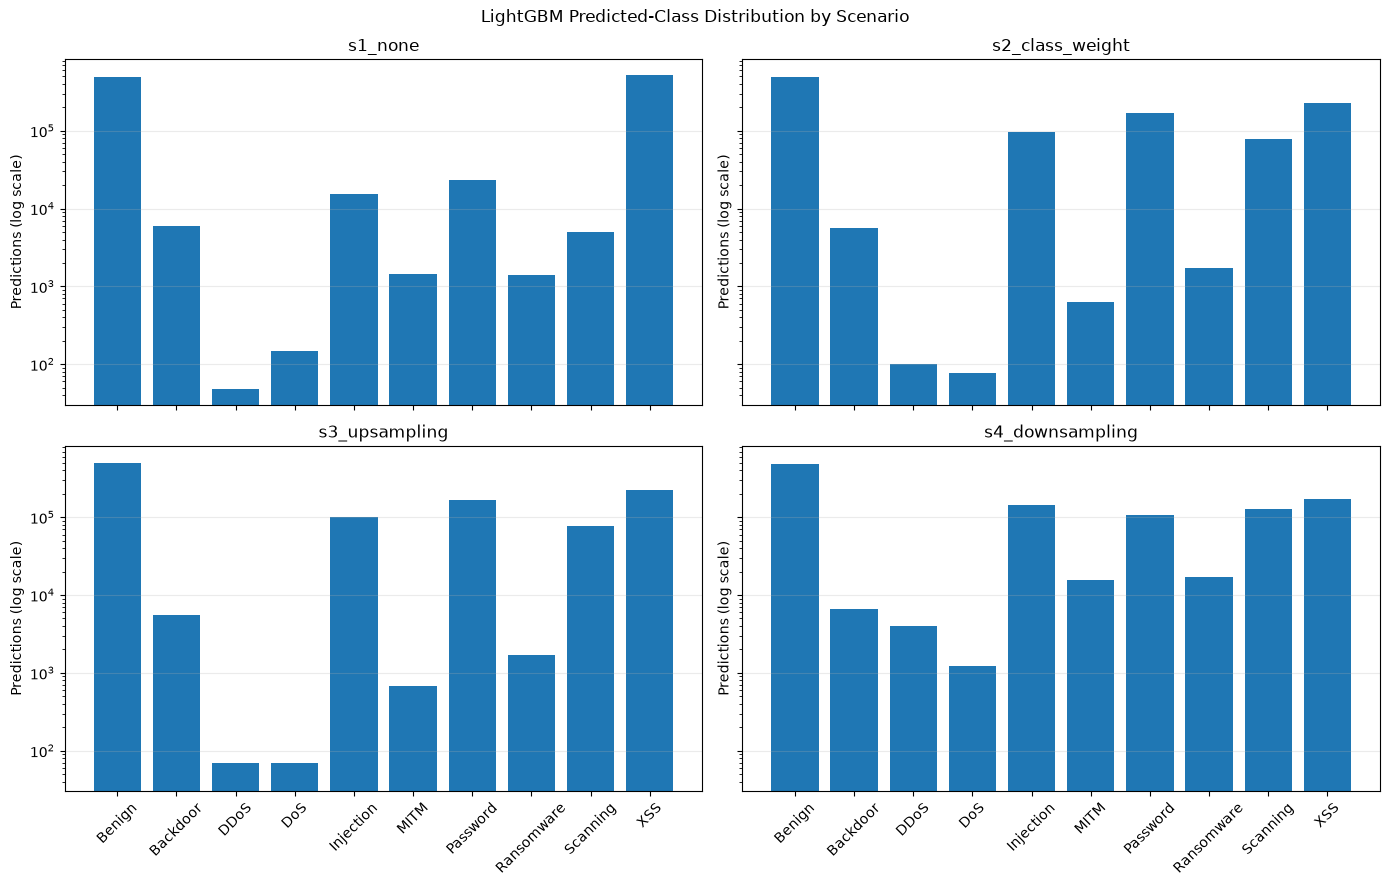

Saved figure: e:\Paper Multiclass-Intrusion-Detection-System\results\figures\lightgbm_prediction_distribution.png


In [7]:
# Cell 7 - Visualize prediction counts as a pre-evaluation sanity check.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, scenario in zip(axes.flat, scenarios):
    frame = prediction_distribution[prediction_distribution['scenario'] == scenario]
    axis.bar(frame['class_name'], frame['prediction_count'])
    axis.set_title(scenario)
    axis.set_yscale('log')
    axis.set_ylabel('Predictions (log scale)')
    axis.tick_params(axis='x', rotation=45)
    axis.grid(axis='y', alpha=0.25)

fig.suptitle('LightGBM Predicted-Class Distribution by Scenario')
fig.tight_layout()
figure_path = figures_dir / 'lightgbm_prediction_distribution.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved figure: {figure_path}')

In [8]:
# Cell 8 - List the model and prediction artifacts ready for Phase 7 evaluation.
artifact_summary = pd.DataFrame([
    {
        'scenario': report['scenario'],
        'model': report['model_path'],
        'predictions': report['prediction_path'],
        'all_classes_predicted': report['all_configured_classes_predicted'],
    }
    for report in classifier_reports.values()
])
display(artifact_summary)
print('Phase 6 artifacts are ready for Phase 7 evaluation.')

,scenario,model,predictions,all_classes_predicted
0,s1_none,E:\Paper Multiclass-Intrusion-Detection-System...,E:\Paper Multiclass-Intrusion-Detection-System...,True
1,s2_class_weight,E:\Paper Multiclass-Intrusion-Detection-System...,E:\Paper Multiclass-Intrusion-Detection-System...,True
2,s3_upsampling,E:\Paper Multiclass-Intrusion-Detection-System...,E:\Paper Multiclass-Intrusion-Detection-System...,True
3,s4_downsampling,E:\Paper Multiclass-Intrusion-Detection-System...,E:\Paper Multiclass-Intrusion-Detection-System...,True


Phase 6 artifacts are ready for Phase 7 evaluation.
